In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization styles
sns.set_theme(style="whitegrid")

# 1. Create a connection to the SQLite database
# Adjust the path if your notebook is in a different relative location
db_path = '../data/database/loan_data.db' 
conn = sqlite3.connect(db_path)

print("Successfully connected to the database!")

Successfully connected to the database!


In [2]:
# 2. Run a basic SQL query
query_count = """
SELECT COUNT(*) as total_rows 
FROM loans;
"""

# Use pandas to run the query and return a DataFrame
row_count_df = pd.read_sql_query(query_count, conn)
print(row_count_df)

   total_rows
0     2260701


,loan_status,count
0,Fully Paid,1076751
1,Current,878317
2,Charged Off,268559
3,Late (31-120 days),21467
4,In Grace Period,8436
5,Late (16-30 days),4349
6,Does not meet the credit policy. Status:Fully ...,1988
7,Does not meet the credit policy. Status:Charge...,761
8,Default,40
9,None,33


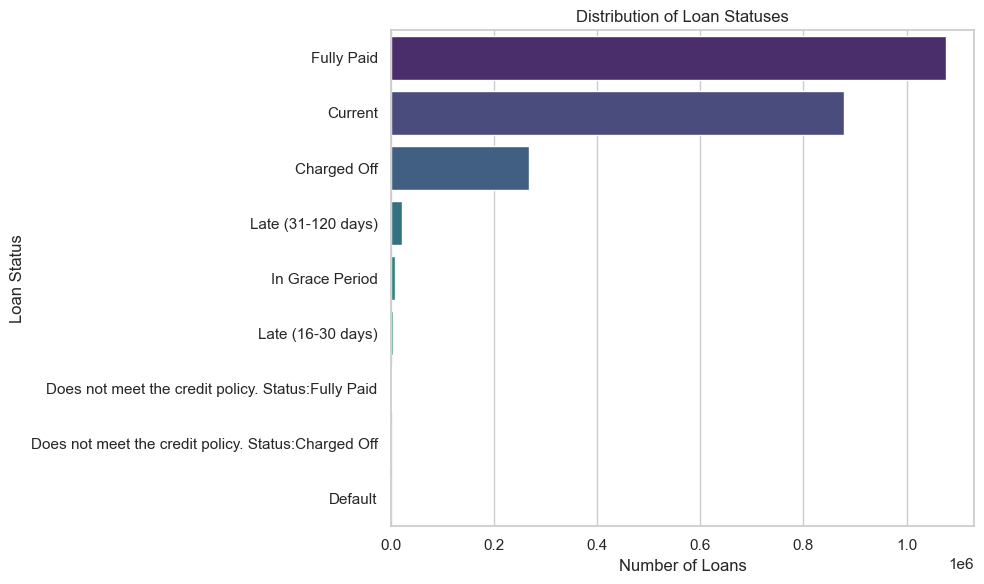

In [3]:
# 3. Aggregate the loan statuses using SQL
query_status = """
SELECT 
    loan_status, 
    COUNT(*) as count
FROM loans
GROUP BY loan_status
ORDER BY count DESC;
"""

status_df = pd.read_sql_query(query_status, conn)

# Display the results
display(status_df)

# Plot it to visualize the class imbalance
plt.figure(figsize=(10, 6))

# UPDATED LINE: Added hue and legend parameters
sns.barplot(
    data=status_df, 
    y='loan_status', 
    x='count', 
    hue='loan_status', 
    palette='viridis', 
    legend=False
)

plt.title("Distribution of Loan Statuses")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Status")
plt.tight_layout()
plt.show()

In [4]:
# 4. Pull a clean dataset with the engineered target variable
query_clean_data = """
SELECT 
    loan_amnt,
    term,
    int_rate,
    installment,
    grade,
    emp_length,
    home_ownership,
    annual_inc,
    verification_status,
    purpose,
    dti,
    delinq_2yrs,
    fico_range_low,
    revol_util,
    CASE 
        WHEN loan_status = 'Fully Paid' THEN 0
        WHEN loan_status IN ('Charged Off', 'Default') THEN 1
    END AS is_default
FROM loans
WHERE loan_status IN ('Fully Paid', 'Charged Off', 'Default');
"""

# Load the filtered data into a new Pandas DataFrame
print("Querying database... this may take a few seconds.")
df = pd.read_sql_query(query_clean_data, conn)

print("Data loaded successfully!")

Querying database... this may take a few seconds.
Data loaded successfully!


In [5]:
# 5. Check the distribution of our new target variable
print(f"Total historical loans for modeling: {len(df):,}\n")

# Get the raw counts
default_counts = df['is_default'].value_counts()
print("Raw Counts:")
print(default_counts)

# Get the percentages
default_percentages = df['is_default'].value_counts(normalize=True) * 100
print("\nPercentages:")
print(default_percentages.round(2).astype(str) + '%')

Total historical loans for modeling: 1,345,350

Raw Counts:
is_default
0    1076751
1     268599
Name: count, dtype: int64

Percentages:
is_default
0    80.04%
1    19.96%
Name: proportion, dtype: object


In [6]:
# 6. Clean text columns and convert to numeric

# Remove '%' from int_rate and revol_util, then convert to float
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)
df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '').astype(float)

# Extract the number from the 'term' column (e.g., " 36 months" -> 36.0)
# The '\d+' is a Regular Expression (Regex) that finds the first block of numbers
df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

# Clean emp_length (e.g., "10+ years" -> 10.0, "< 1 year" -> 0.0)
df['emp_length'] = df['emp_length'].astype(str).str.replace('< 1', '0')
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

# Check the data types to confirm our changes worked
print("New Data Types:")
print(df[['int_rate', 'revol_util', 'term', 'emp_length']].dtypes)

print("\nSample of the cleaned columns:")
display(df[['int_rate', 'revol_util', 'term', 'emp_length']].head())

New Data Types:
int_rate      float64
revol_util    float64
term          float64
emp_length    float64
dtype: object

Sample of the cleaned columns:


,int_rate,revol_util,term,emp_length
0,13.99,29.7,36.0,10.0
1,11.99,19.2,36.0,10.0
2,10.78,56.2,60.0,10.0
3,22.45,64.5,60.0,3.0
4,13.44,68.4,36.0,4.0


In [7]:
# 7. Check for missing values
print("Missing values per column:")
missing_data = df.isnull().sum()

# Only show columns that actually have missing data, sorted highest to lowest
print(missing_data[missing_data > 0].sort_values(ascending=False))

Missing values per column:
emp_length    78516
revol_util      857
dti             374
dtype: int64


In [8]:
# 8. Handle Missing Values

# For numeric columns like employment length or revolving utilization, fill with the Median
for col in ['emp_length', 'revol_util', 'dti', 'annual_inc']:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

# For categorical text columns, fill with "Unknown" or the Mode
# 'title' and 'emp_title' often have missing values in this dataset
if 'emp_title' in df.columns:
    df['emp_title'] = df['emp_title'].fillna('Unknown')

# Drop any remaining rows that still have NaNs in critical columns (just to be safe)
df = df.dropna()

print(f"Data cleaning complete! Remaining rows for modeling: {len(df):,}")

Data cleaning complete! Remaining rows for modeling: 1,345,350


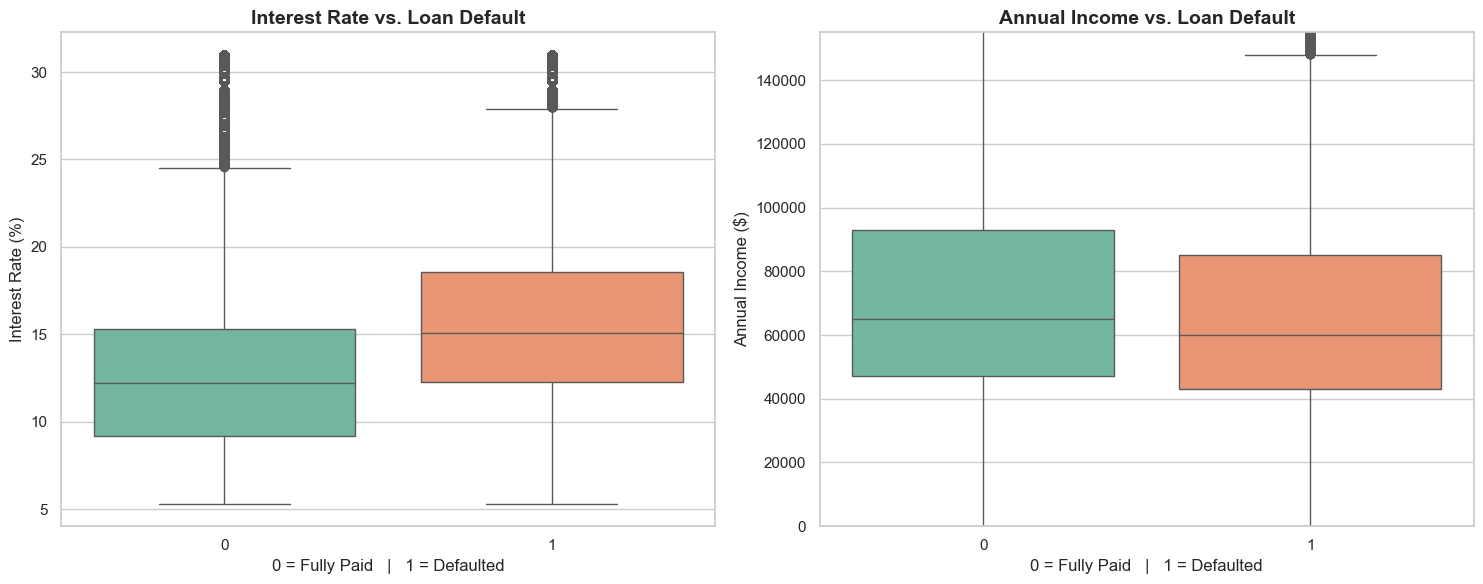

In [9]:
# 9. Visualizing Key Features vs. Target Variable
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a clean, professional look
sns.set_theme(style="whitegrid")

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Interest Rate vs. Default ---
sns.boxplot(
    data=df, 
    x='is_default', 
    y='int_rate', 
    ax=axes[0], 
    hue='is_default', 
    palette='Set2', 
    legend=False
)
axes[0].set_title("Interest Rate vs. Loan Default", fontsize=14, fontweight='bold')
axes[0].set_xlabel("0 = Fully Paid   |   1 = Defaulted", fontsize=12)
axes[0].set_ylabel("Interest Rate (%)", fontsize=12)

# --- Plot 2: Annual Income vs. Default ---
# PRO-TIP: Income data always has massive outliers (e.g., someone claiming $5M/year).
# If we don't cap the y-axis, the boxplot will be squished to a tiny line.
# We will calculate the 95th percentile and cap the visual there.
income_cap = df['annual_inc'].quantile(0.95)

sns.boxplot(
    data=df, 
    x='is_default', 
    y='annual_inc', 
    ax=axes[1], 
    hue='is_default', 
    palette='Set2', 
    legend=False
)
axes[1].set_title("Annual Income vs. Loan Default", fontsize=14, fontweight='bold')
axes[1].set_xlabel("0 = Fully Paid   |   1 = Defaulted", fontsize=12)
axes[1].set_ylabel("Annual Income ($)", fontsize=12)
axes[1].set_ylim(0, income_cap) # Apply our outlier cap

# Adjust layout and display
plt.tight_layout()
plt.show()

In [10]:
# 10. One-Hot Encoding Categorical Variables

# List the text columns we need to convert
categorical_cols = ['grade', 'home_ownership', 'verification_status', 'purpose']

# Use pandas get_dummies to convert text categories into binary (1/0) columns
# We use drop_first=True to avoid the "Dummy Variable Trap" (multicollinearity)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert all the new boolean (True/False) columns to integers (1/0)
# (Newer versions of pandas return booleans for get_dummies)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# Verify the transformation
print(f"Original column count: {len(df.columns)}")
print(f"New column count after encoding: {len(df_encoded.columns)}\n")

print("Data types of the newly created columns (Notice they are all numbers now!):")
# Show just a few of the newly created columns to confirm
display(df_encoded.filter(like='home_ownership').head())

Original column count: 15
New column count after encoding: 37

Data types of the newly created columns (Notice they are all numbers now!):


,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,0,0,0,0,1


In [11]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.6/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
# 11. Train/Test Split and Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Separate the features (X) from the target variable (y)
X = df_encoded.drop('is_default', axis=1)
y = df_encoded['is_default']

# Split the data into 80% training and 20% testing
# 'stratify=y' ensures the 80/20 class imbalance is perfectly maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features so all numbers are on a level playing field
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model
# We use class_weight='balanced' to force the model to pay extra attention to the rare defaults!
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

print("Training the Logistic Regression model... this might take a minute.")
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the unseen test data
y_pred = log_reg.predict(X_test_scaled)

# Evaluate the results
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Training the Logistic Regression model... this might take a minute.

--- Confusion Matrix ---
[[135490  79860]
 [ 17765  35955]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.63      0.74    215350
           1       0.31      0.67      0.42     53720

    accuracy                           0.64    269070
   macro avg       0.60      0.65      0.58    269070
weighted avg       0.77      0.64      0.67    269070



In [13]:
# 12. Train an Advanced Model: Random Forest
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest
# n_jobs=-1 uses all available CPU cores to speed up training
# max_depth=10 keeps the model from overfitting and crashing your RAM
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

print("Training Random Forest... grab a coffee, this might take a few minutes!")
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the new results
print("\n--- Random Forest Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_rf))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

Training Random Forest... grab a coffee, this might take a few minutes!

--- Random Forest Confusion Matrix ---
[[134039  81311]
 [ 17354  36366]]

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.62      0.73    215350
           1       0.31      0.68      0.42     53720

    accuracy                           0.63    269070
   macro avg       0.60      0.65      0.58    269070
weighted avg       0.77      0.63      0.67    269070



In [14]:
# 14. Testing a Deeper Tree for Overfitting
print("Training deeper Random Forest (max_depth=20)...")

rf_deep = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20, # Doubled the depth!
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

rf_deep.fit(X_train_scaled, y_train)

# Predict on both sets to check for overfitting
y_train_pred = rf_deep.predict(X_train_scaled)
y_test_pred = rf_deep.predict(X_test_scaled)

print("\n--- PERFORMANCE ON TRAINING DATA (Did it memorize?) ---")
print(classification_report(y_train, y_train_pred))

print("\n--- PERFORMANCE ON UNSEEN TEST DATA (Did it generalize?) ---")
print(classification_report(y_test, y_test_pred))

Training deeper Random Forest (max_depth=20)...

--- PERFORMANCE ON TRAINING DATA (Did it memorize?) ---
              precision    recall  f1-score   support

           0       0.94      0.82      0.88    861401
           1       0.52      0.79      0.63    214879

    accuracy                           0.82   1076280
   macro avg       0.73      0.80      0.75   1076280
weighted avg       0.86      0.82      0.83   1076280


--- PERFORMANCE ON UNSEEN TEST DATA (Did it generalize?) ---
              precision    recall  f1-score   support

           0       0.86      0.77      0.81    215350
           1       0.35      0.50      0.41     53720

    accuracy                           0.72    269070
   macro avg       0.61      0.63      0.61    269070
weighted avg       0.76      0.72      0.73    269070



In [15]:
%pip install xgboost


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.3.6/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
# 15. The Industry Standard: XGBoost
import xgboost as xgb

# Calculate the ratio of negative class (0) to positive class (1) for balancing
# This tells XGBoost to pay way more attention to the defaults
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,         # XGBoost uses shallower trees than Random Forest
    learning_rate=0.1,   # How aggressively it tries to fix mistakes
    scale_pos_weight=ratio, 
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost... this algorithm is highly optimized!")
xgb_model.fit(X_train_scaled, y_train)

# Predict on the unseen test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\n--- XGBoost Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost... this algorithm is highly optimized!

--- XGBoost Confusion Matrix ---
[[136821  78529]
 [ 17436  36284]]

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.64      0.74    215350
           1       0.32      0.68      0.43     53720

    accuracy                           0.64    269070
   macro avg       0.60      0.66      0.59    269070
weighted avg       0.77      0.64      0.68    269070



In [18]:
# 16. Exporting XGBoost Predictions for Tableau
import os

# Get the exact probability of default (from 0.0 to 1.0) using our best model
probabilities = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Reconstruct a clean DataFrame using the original, unscaled test data
results_df = df.loc[X_test.index].copy()

# Attach our model's findings
results_df['Actual_Default'] = y_test
results_df['Predicted_Default'] = y_pred_xgb
results_df['Default_Probability'] = probabilities

# Filter down to the most important columns for Tableau
cols_to_keep = [
    'loan_amnt', 'term', 'int_rate', 'grade', 'annual_inc', 
    'home_ownership', 'purpose', 'Actual_Default', 
    'Predicted_Default', 'Default_Probability'
]
tableau_df = results_df[cols_to_keep]

# --- THE FIX IS HERE ---
# Define the directory and create it if it doesn't exist
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Now safely save it to the newly guaranteed folder
output_path = f'{output_dir}/xgboost_risk_scores.csv'
tableau_df.to_csv(output_path, index=False)

print(f"Success! Exported {len(tableau_df):,} rows to {output_path}")
display(tableau_df.head())

Success! Exported 269,070 rows to ../data/processed/xgboost_risk_scores.csv


,loan_amnt,term,int_rate,grade,annual_inc,home_ownership,purpose,Actual_Default,Predicted_Default,Default_Probability
167063,11925.0,36.0,6.24,A,47819.0,MORTGAGE,credit_card,0,0,0.098674
571419,25000.0,36.0,11.99,C,130000.0,OWN,debt_consolidation,1,0,0.433891
668923,12000.0,36.0,8.49,B,59000.0,MORTGAGE,credit_card,0,0,0.237131
381745,3000.0,36.0,7.96,A,115000.0,MORTGAGE,home_improvement,0,0,0.230670
83718,8000.0,36.0,9.99,B,115000.0,MORTGAGE,other,0,0,0.294110
